In [1]:
# univariate lstm example
from numpy import array
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
import numpy as np
import pandas as pd
import tensorflow as tf

In [2]:
# split a univariate sequence into samples
def split_sequence(sequence, n_steps):
    X, y = list(), list()
    for i in range(len(sequence)):
        # find the end of this pattern
        end_ix = i + n_steps
        # check if we are beyond the sequence
        if end_ix > len(sequence)-1:
            break
        # gather input and output parts of the pattern
        seq_x, seq_y = sequence[i:end_ix], sequence[end_ix]
        X.append(seq_x)
        y.append(seq_y)
    return array(X), array(y)



In [3]:
# define input sequence
parser = (lambda x:datetime.datetime.strptime(x, '%Y.%m.%d')) 
df = pd.read_csv('sp_beaches_update.csv', parse_dates=['Date'])
df = df.sort_values(by=['Date'])
df=df.loc[~df['Enterococcus'].isnull()]
#remover a praia do Leste, da cidade de iguape, pois esta praia sumiu por erosão em 2012
#remover a Lagoa Prumirim, da cidade de Ubatuba, pois esta praia possui somente 3 medições
df = df.loc[df['Beach']!='DO LESTE'].loc[df['Beach']!='LAGOA PRUMIRIM']
df.info()



<class 'pandas.core.frame.DataFrame'>
Int64Index: 69016 entries, 0 to 66721
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   City          69016 non-null  object        
 1   Beach         69016 non-null  object        
 2   Date          69016 non-null  datetime64[ns]
 3   Enterococcus  69016 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 2.6+ MB


In [4]:
cidade="UBATUBA"
praia="GRANDE"

df_beach = df.loc[df['City']==cidade].loc[df['Beach']==praia][['Date','Enterococcus']]
df_beach.columns = ['ds', 'y']
df_beach.set_index('ds', inplace=True)
df_beach

,y
ds,
2012-01-03,5
2012-01-08,42
2012-01-15,92
2012-01-22,16
2012-01-29,9
...,...
2020-08-31,2
2020-09-07,17
2020-09-14,14


In [42]:
# choose a number of time steps
n_steps = 16


In [43]:
# split into samples
X, y = split_sequence(df_beach.values, n_steps)
X.shape

(413, 16, 1)

In [44]:
y.shape

(413, 1)

In [45]:
# reshape from [samples, timesteps] into [samples, timesteps, features]
n_features = 1
X = X.reshape((X.shape[0], X.shape[1], n_features))


In [46]:
# define model
model = Sequential()
model.add(LSTM(104, activation='relu', return_sequences=True, input_shape=(n_steps, n_features)))
model.add(LSTM(104, activation='relu'))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')


In [47]:
# fit model
with tf.device('/GPU:0'): 
    R = model.fit(X, y, epochs=200, verbose=1)
R


Train on 413 samples
Epoch 1/200
413/413 [==============================] - 2s 5ms/sample - loss: 852.0567
Epoch 2/200
413/413 [==============================] - 0s 639us/sample - loss: 747.8981
Epoch 3/200
413/413 [==============================] - 0s 636us/sample - loss: 741.4325
Epoch 4/200
413/413 [==============================] - 0s 603us/sample - loss: 723.1329
Epoch 5/200
413/413 [==============================] - 0s 623us/sample - loss: 722.0020
Epoch 6/200
413/413 [==============================] - 0s 610us/sample - loss: 700.4102
Epoch 7/200
413/413 [==============================] - 0s 618us/sample - loss: 721.2168
Epoch 8/200
413/413 [==============================] - 0s 612us/sample - loss: 732.3827
Epoch 9/200
413/413 [==============================] - 0s 629us/sample - loss: 705.8906
Epoch 10/200
413/413 [==============================] - 0s 654us/sample - loss: 686.3537
Epoch 11/200
413/413 [==============================] - 0s 623us/sample - loss: 675.5947
Epoch 12/20

Epoch 185/200
413/413 [==============================] - 0s 657us/sample - loss: 0.9972
Epoch 186/200
413/413 [==============================] - 0s 683us/sample - loss: 1.1547
Epoch 187/200
413/413 [==============================] - 0s 656us/sample - loss: 1.3617
Epoch 188/200
413/413 [==============================] - 0s 668us/sample - loss: 1.3802
Epoch 189/200
413/413 [==============================] - 0s 682us/sample - loss: 1.3916
Epoch 190/200
413/413 [==============================] - 0s 648us/sample - loss: 1.0472
Epoch 191/200
413/413 [==============================] - 0s 662us/sample - loss: 1.3619
Epoch 192/200
413/413 [==============================] - 0s 627us/sample - loss: 1.1360
Epoch 193/200
413/413 [==============================] - 0s 647us/sample - loss: 0.7972
Epoch 194/200
413/413 [==============================] - 0s 666us/sample - loss: 0.9931
Epoch 195/200
413/413 [==============================] - 0s 669us/sample - loss: 1.1683
Epoch 196/200
413/413 [=========

In [48]:
round(R.history['loss'][-1])#4:60 - 8: 136 - 12: 610 - 16:856

0

In [49]:
# demonstrate prediction loss: 944.5669 - loss: 738.7696 - loss: 978.6097 -  loss: 20774.2353
#x_input = y[-6:-2]
#x_input = x_input.reshape((1, n_steps, n_features))
yhat = model.predict(X, verbose=1)
print(y)
print(yhat)

413/413 [==============================] - 0s 845us/sample
[[ 39]
 [  3]
 [  1]
 [  6]
 [  1]
 [  4]
 [  2]
 [  1]
 [  1]
 [  1]
 [  3]
 [  4]
 [ 24]
 [  1]
 [  5]
 [  2]
 [  4]
 [  1]
 [ 17]
 [  3]
 [ 16]
 [  4]
 [  1]
 [  5]
 [  1]
 [ 10]
 [  8]
 [  5]
 [  1]
 [  9]
 [ 19]
 [ 14]
 [ 10]
 [  9]
 [ 19]
 [  7]
 [ 16]
 [ 12]
 [  7]
 [ 54]
 [ 56]
 [  1]
 [  2]
 [ 15]
 [ 28]
 [  9]
 [  5]
 [ 88]
 [ 24]
 [ 27]
 [  6]
 [ 25]
 [ 16]
 [  1]
 [  1]
 [  2]
 [  1]
 [  6]
 [  1]
 [  1]
 [  2]
 [  1]
 [ 32]
 [  2]
 [  1]
 [  7]
 [  5]
 [ 13]
 [  1]
 [ 12]
 [  3]
 [  1]
 [  4]
 [  6]
 [  1]
 [  1]
 [  4]
 [ 36]
 [  6]
 [  4]
 [  6]
 [  1]
 [ 12]
 [ 38]
 [ 12]
 [ 18]
 [ 12]
 [ 12]
 [ 44]
 [ 12]
 [ 28]
 [156]
 [ 15]
 [ 36]
 [  1]
 [  9]
 [ 28]
 [ 10]
 [  6]
 [ 15]
 [  4]
 [  3]
 [ 16]
 [  1]
 [  2]
 [  1]
 [  3]
 [  1]
 [  1]
 [  1]
 [  3]
 [ 40]
 [  3]
 [  1]
 [ 17]
 [  3]
 [  2]
 [  1]
 [ 30]
 [180]
 [  5]
 [  3]
 [  7]
 [  2]
 [ 12]
 [  4]
 [ 12]
 [  1]
 [ 10]
 [ 17]
 [ 20]
 [ 90]
 [ 65]
 [ 30]
 [ 

<AxesSubplot:>

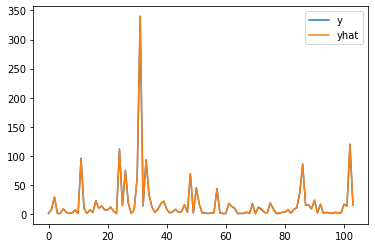

In [50]:
ultimos = 104
pd.DataFrame({'y':y[-ultimos:].reshape((ultimos)),'yhat':yhat[-ultimos:].reshape((ultimos))}).plot()


<AxesSubplot:xlabel='ds'>

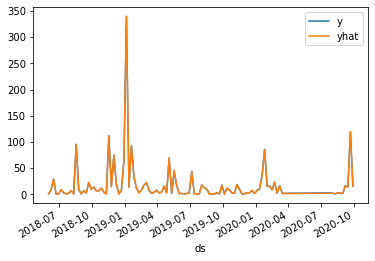

In [51]:
#s1 = pd.Series(yhat.reshape((377)), name='yhat').reindex(df_beach.index)
s1 = pd.DataFrame({'yhat':yhat.reshape((y.shape[0]))}, index=df_beach.index[-y.shape[0]:])
#s1
result = pd.concat([df_beach.iloc[-y.shape[0]:], s1], axis=1)
result.iloc[-104:].plot()

In [29]:
model.save('LSTM_UBATUBA_GRANDE.h5')